In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Apple SD Gothic Neo'

In [2]:
train1 = pd.read_csv('../data/1차 전처리(센서 제거)/train1_sens_filter.csv',index_col=0)
train1.head()

,engine_id,cycle,op1,op2,op3,s2,s3,s4,s7,s8,s9,s11,s12,s13,s14,s15,s17,s20,s21,RUL
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187


In [42]:
sensor_cols = ['s2', 's3', 's4', 's7', 's8','s9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']

In [19]:
def plot_sensor_grid(df, engine_id, subset_name="FD001", ncols=3, save_path=None):
    """엔진 하나의 21개 센서를 사이클에 따라 그리드로 그린다.
    각 서브플롯이 독립적인 y축을 쓰기 때문에, 센서 간 스케일 차이에 관계없이
    추세(오르는지/내리는지/그대로인지)를 한눈에 비교할 수 있다.
    """
    engine = df[df["engine_id"] == engine_id]
    sensor_cols = ['s2', 's3', 's4', 's7', 's8','s9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
    nrows = -(-len(sensor_cols) // ncols)  # 올림 나눗셈

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.5 * nrows), sharex=True)
    axes = axes.flatten()

    for ax, col in zip(axes, sensor_cols):
        ax.plot(engine["cycle"], engine[col], linewidth=1, color="#4C72B0")
        ax.set_title(col, fontsize=10)
        ax.grid(True, linewidth=0.4, alpha=0.4)
        ax.tick_params(labelsize=8)
        

    for ax in axes[len(sensor_cols):]:
        ax.axis("off")

    fig.suptitle(f"{subset_name} - Engine {engine_id} - 14 sensors over cycles", fontsize=13)
    fig.supxlabel("cycle")
    fig.tight_layout(rect=[0, 0, 1, 0.97])

    if save_path:
        fig.savefig(save_path, dpi=110)
    return fig

### 이상치 확인

- 결측치
- 물리적으로 불가능한 값(센서 범위를 벗어난 값)

초기 RUL에서의 튀는 값은 이상치, 말기 RUL에서의 튀는 값은 열화에 영향을 주는 값일 수도 있음.

일단, 센서 1개를 사이클마다 그려보고 추세선 주변에 얼마나 흔들림이 있는지 확인해보자.


특징
- 중간중간 확 튀는 스파이크성 노이즈가 보인다. 
- 초반 100사이클까지는 추세가 거의 보이지 않는다. 이후 100-150까지 조금 오른 상태이며, 이후 175-200에서 좀 더 가파른 상승을 보인다. 그렇다면 RUL 상한을 100 이상으로 생각해볼 수 있겠다.
- 고장까지 상승 추세선이므로 해당 센서는 온도에 관련된 센서로 추측할 수 있다.


다른 센서도 확인해보자.


같은 센서2의 engine_id만 다르게 해서 확인했을 때, 해당 센서의 수명은 약 300사이클이다. 
추세선은 약 150(2분의 1)까지는 미미한 상승을 보이며, 이후 상승 곡선이 가파르다. 

4번 엔진의 경우 더 확실한 차이를 볼 수 있다. 수명은 약 180회이며, 125사이클까지는 추세가 거의 평평하다. 이후엔 상승한댜. 

-> 따라서 s2같은 경우, 수명의 2분의 1까지는 추세가 상승하거나 하락하지 않고 그대로 유지되는 것을 확인할 수 있다.

각 센서들의 노이즈 유형을 파악하기 위해서 모든 센서를 서브플롯으로 띄워보자.

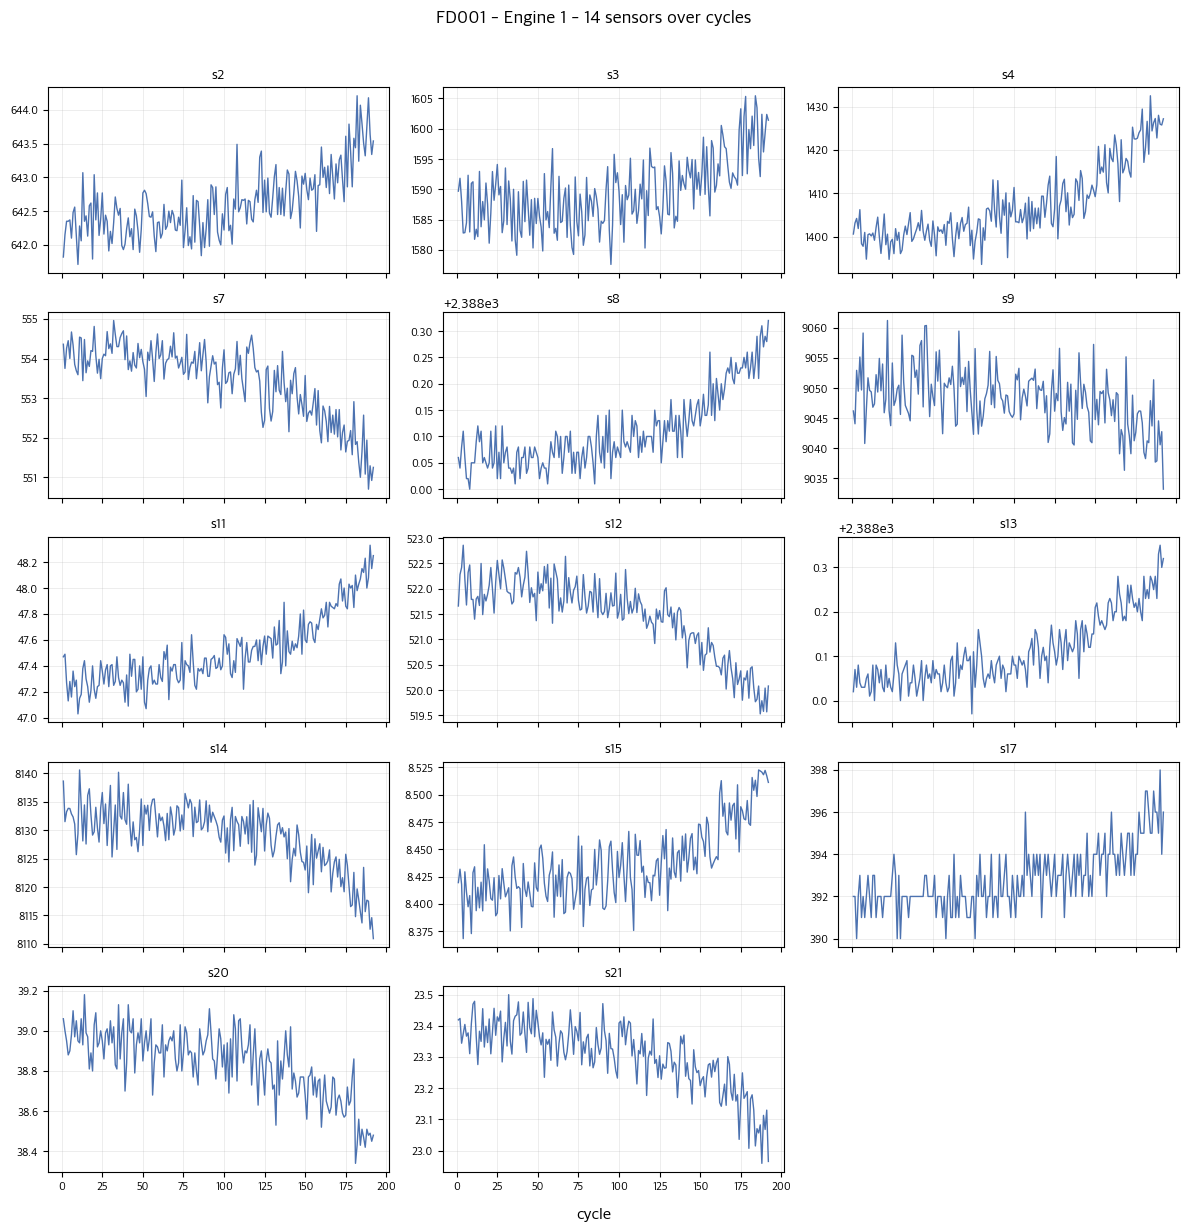

In [20]:
fig = plot_sensor_grid(train1, engine_id=1)

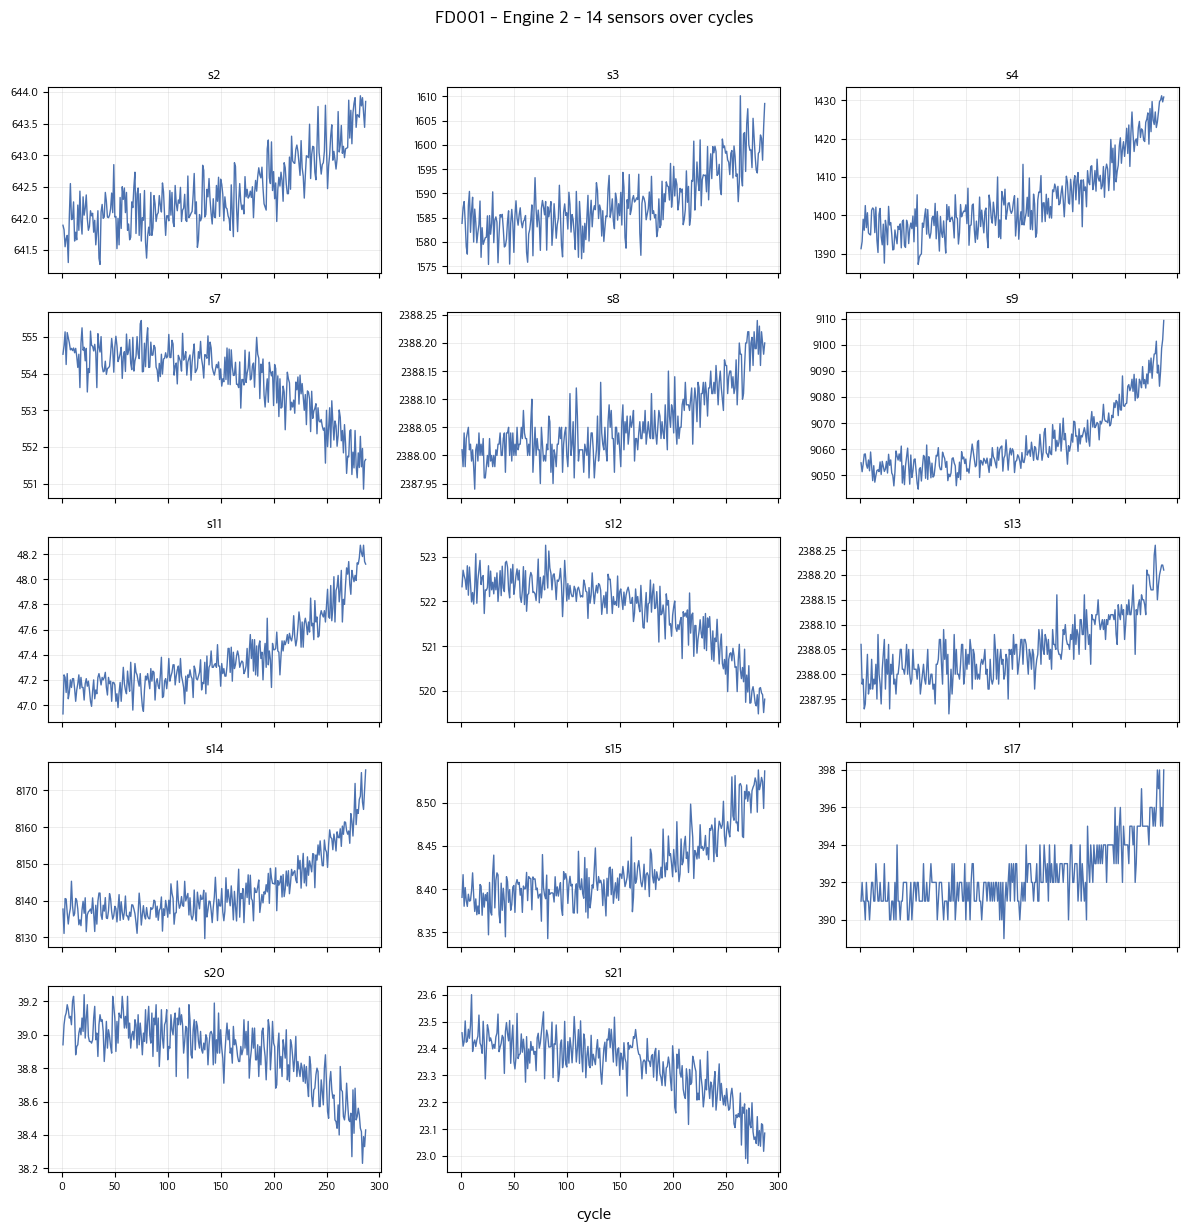

In [21]:
fig = plot_sensor_grid(train1, engine_id=2)

### 노이즈 유형 추정

- 드리프트 : 해당 데이터는 c-mapss데이터로 실제 센서가 아닌 시뮬레이터 데이터이기 때문에, 센서 자체의 노후현상까지 시뮬레이터에 포함시켰을 가능성이 낮음. 따라서 드리프트 현상은 고려하지 않음
- 양자화 노이즈 : s17에서 양자화 노이즈의 가능성이 있지만, 대부분의 센서는 양자화 노이즈(계단식)의 양상이 나타나지 않으므로 고려하지 않음. 추후에 s17만 추가적으로 진행하는 것을 고려
- 주기성 간섭 : 현재 다루고있는 FD001은 운전 조건이 한가지이므로 주기성 간섭이 생길 가능성이 매우적음. 따라서 고려하지 않음.
- 스파이크 : 14개의 센서를 그래프로 확인했을 때 가장 가능성이 높음. 실제로 정상 범위에서 벗어났다가 다시 돌아오는 수치들을 눈으로도 확인할 수 있음.



### 정규 분포인가?

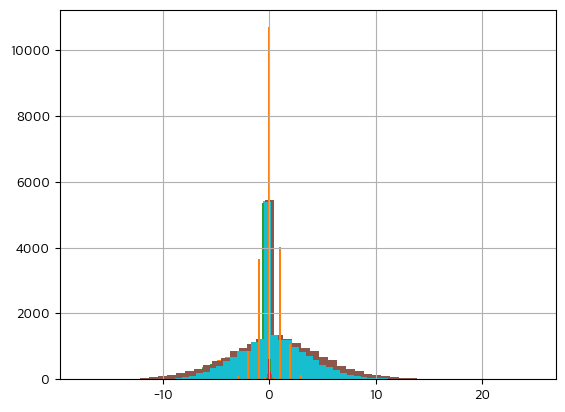

In [46]:
for col in sensor_cols:
    residual = train1.groupby("engine_id")[col].transform(
        lambda x: x - x.rolling(5, min_periods=1).median()
    )
    residual.hist(bins=50)

### 모든 센서의 분포를 확인했을 때 정규분포를 이룸 -> 정규분포를 가정하는 필터링 기법 사용가능 = hampel filter(스파이크값 탐지)

### why 헴펠필터?
헴펠필터 : 설정된 윈도우의 중앙값의 3*mad값을 벗어나는 값을 이상치로 판단함

- 중앙값과 MAD는 이상치가 끼어도 잘 흔들리지 않는 통계임. 평균과 표준편차에 이미 스파이크값들이 들어가서 계산이 되었기 떄문에 이를 이용해 이상치 탐지를 하게되면 기준선이 이상치쪽으로 끌려가는 순환 오염이 발생함.
- 평활화 필터,즉 이동평균이나 저역필터를 사용하게 되면 모든 지점을 건드려서 스무딩하는 기법인데, 그렇게되면 후반부의 중요한 열화신호 또한 뭉개버릴 가능성이 있음. 헴펠필터는 미리 정한 윈도우 범위 안에서의 로컬 임계치를 기준으로 제거하기 떄문에, 초반부 신호에 영향받지 않음. 



<Axes: >

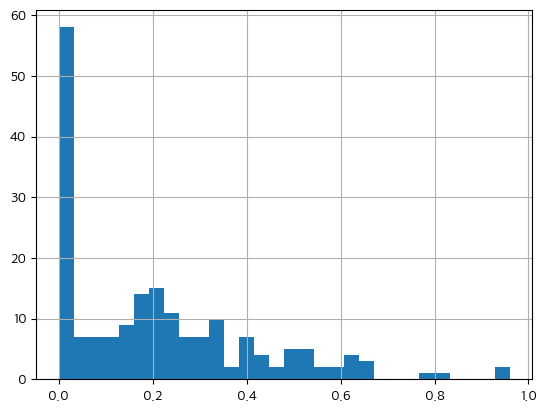

In [ ]:
# 5개 구간마다 평균을 구하고, 기존 값에서 해당 평균을 뺴서 잔차를 구한다 -> 잔차가 0.0~0.2가 가장 많고, 0.8 이상부터는 동떨어져있는 모습을 확인할 수 있다.

deviation = (engine1['s2'] - engine1['s2'].rolling(5, min_periods=1).median()).abs()
deviation.hist(bins=30)

In [69]:
def hampel_filter(series,window=5,k=3,n_sigmas=3):
    rolling_median = series.rolling(window,center=False).median()
    mad = series.rolling(window,center=False).apply(
        lambda x : np.median(np.abs(x-np.median(x))),raw =True
    )
    threshold = k * 1.4826 * mad
    diff = (series - rolling_median).abs()

    outlier = diff > threshold
    filtered = series.copy()
    filtered[outlier] = rolling_median[outlier]
    return filtered, outlier

In [93]:
engine1 = train1[train1['engine_id']==1]
    
filtered_s2, is_outlier_s2 = hampel_filter(engine1['s2'],window=5,k=3)
filtered_s17, is_outlier_s17 = hampel_filter(engine1['s17'],window=8,k=3)

print("이상치 개수 : ",is_outlier_s2.sum())

이상치 개수 :  14


/var/folders/w5/9zknfqrs3dn6cmzpl11fhmmw0000gn/T/ipykernel_81500/2887562009.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[392.  392.  392.  392.5 392.  392.  392.  392.  392.  391.5 392.  394.
 394. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  filtered[outlier] = rolling_median[outlier]


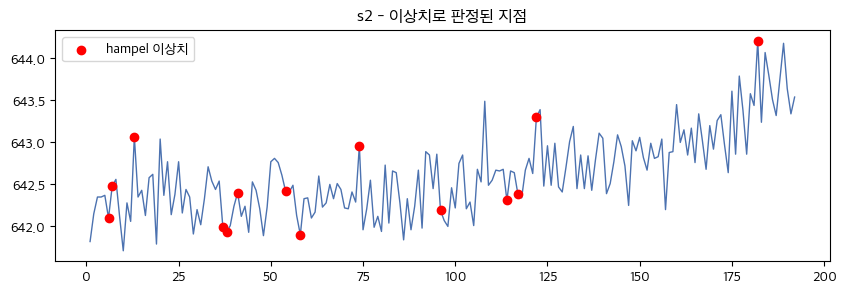

In [94]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(engine1['cycle'], engine1['s2'], linewidth=1, color="#4C72B0")
ax.scatter(engine1['cycle'][is_outlier_s2], engine1['s2'][is_outlier_s2],
           color="red", zorder=5, label="hampel 이상치")
ax.set_title("s2 - 이상치로 판정된 지점")
ax.legend()

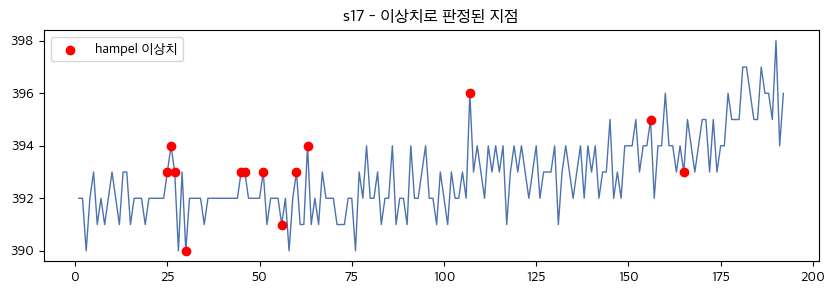

In [95]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(engine1['cycle'], engine1['s17'], linewidth=1, color="#4C72B0")
ax.scatter(engine1['cycle'][is_outlier_s17], engine1['s17'][is_outlier_s17],
           color="red", zorder=5, label="hampel 이상치")
ax.set_title("s17 - 이상치로 판정된 지점")
ax.legend()

### 엔진별로 모든 센서에 필터 적용 후 상관관계 차이 확인
- 상관관계는 스피어만으로 확인 : 보통 열화곡선은 선형 관계가 아님. 초반엔 천천히 변하다가 후반에 갈수록 기울기가 커지는 곡선 형태임. 이럴 경우 피어슨으로 관계 계산시 더 약하게 나옴. 또한 피어슨은 값 자체를 계산하기 때문에 이상치에 민감함. 스피어만은 순위로 바꾸어서 계산하기 떄문에 이상치의 영향을 덜 받음.
- 왜 피어슨은 안되는지 ? : 안된다기보다는 둘의 성격 자체가 다름. 피어슨은 X와 Y에게 직선 관계가 있는지 봄. 즉 x가 커질때 y가 같은 비율로 커지는지 보는것임. 


**분석 목적**   
질문 1: "필터가 값을 많이/크게 바꿨는가?" (이상치가 제거되긴 했는가) : 피어슨   
질문 2: "필터가 열화 추세(진짜 신호)를 건드리지 않고, 노이즈만 건드렸는가?" (정상값을 잘못 건드리지 않았는가) : 스피어만

따라서 둘의 지표를 혼합하여 확인하는 것이 적절함. 

### 결과 
- 필터의 값은 지표로 볼 떄 최소 4%, 최대 10%까지 필터링된 걸로 보았을 때 필터가 과도하게 많은 점을 건드리지 않음.
- 스피어만, 피어슨 모두 확인시 상관관계가 거의 동일함. -> 추세가 보존됨.
- 결론적으로 노이즈는 적당히 걷어냈지만 추세는 보존됨.


/var/folders/w5/9zknfqrs3dn6cmzpl11fhmmw0000gn/T/ipykernel_81500/2887562009.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[392.  392.  392.  392.5 392.  392.  392.  392.  392.  391.5 392.  394.
 394. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  filtered[outlier] = rolling_median[outlier]


,sensor,n_unique,outlier_pct,var_reduction_pct,corr_before,corr_after,corr_change
6,s11,80,10.416667,2.369843,0.842075,0.852644,0.010569
4,s8,32,9.895833,5.009178,0.805492,0.830070,0.024578
5,s9,183,8.333333,11.305422,-0.442325,-0.415095,-0.027230
13,s21,187,8.333333,12.160235,-0.763344,-0.786194,0.022850
0,s2,123,7.291667,8.191861,0.693328,0.711002,0.017674
3,s7,138,7.291667,0.138549,-0.798544,-0.821951,0.023407
7,s12,132,7.291667,3.489359,-0.838586,-0.844339,0.005753
10,s15,178,7.291667,9.309047,0.723805,0.729190,0.005385
12,s20,62,7.291667,4.041277,-0.729856,-0.739181,0.009324
11,s17,9,6.770833,4.409187,0.685718,0.721599,0.035880


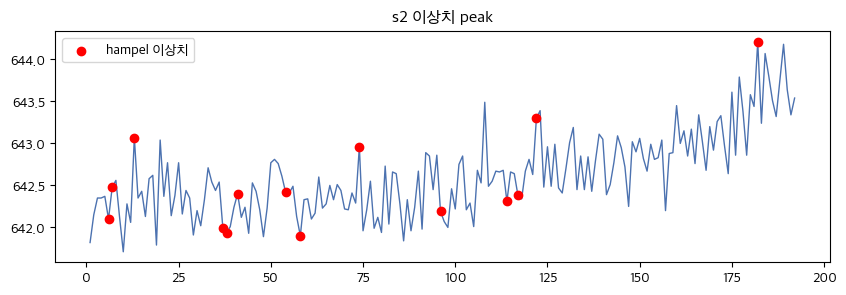

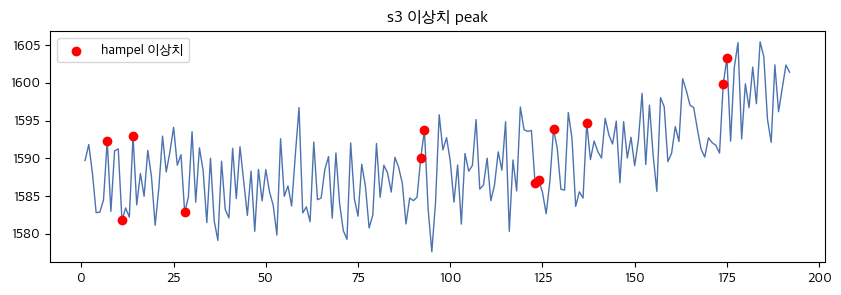

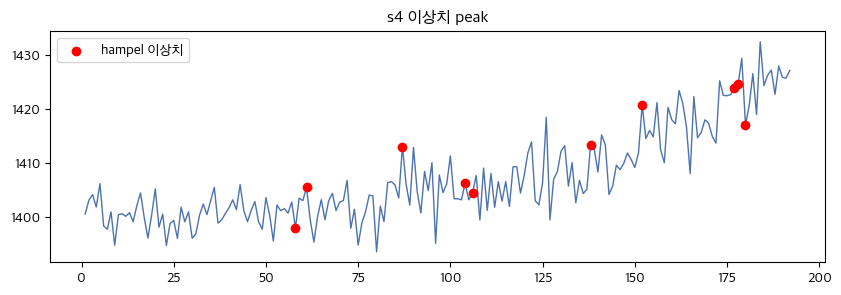

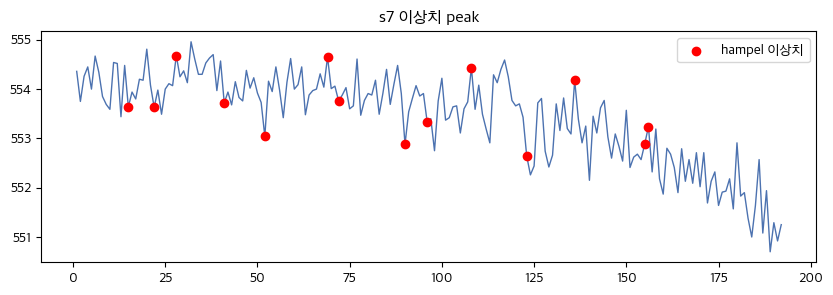

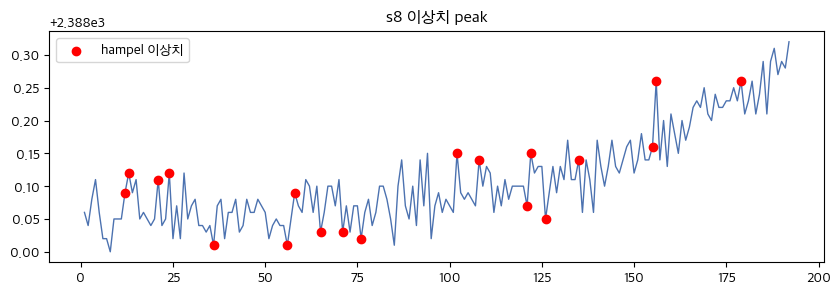

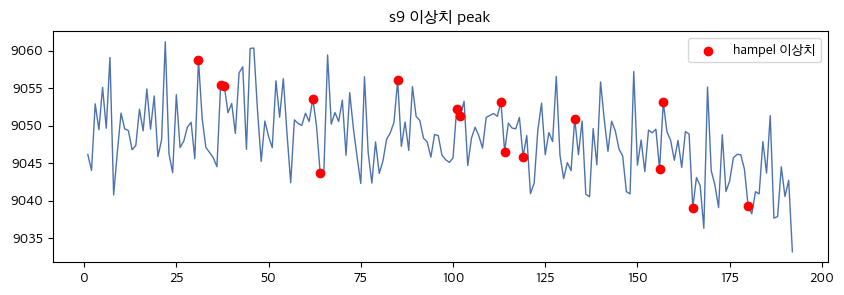

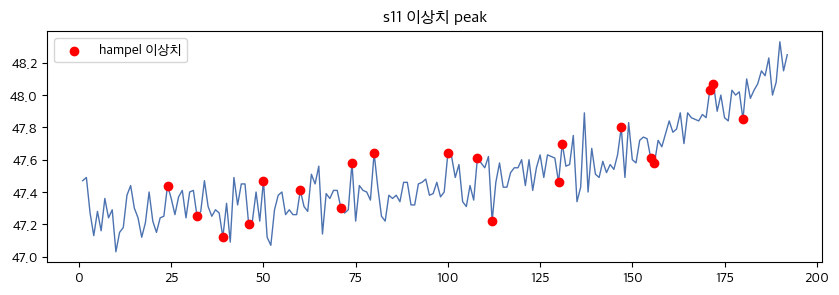

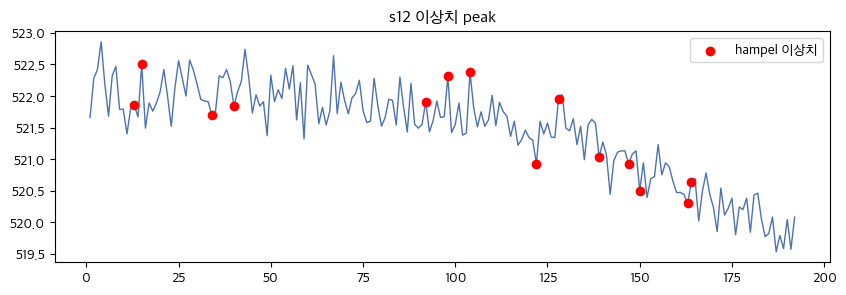

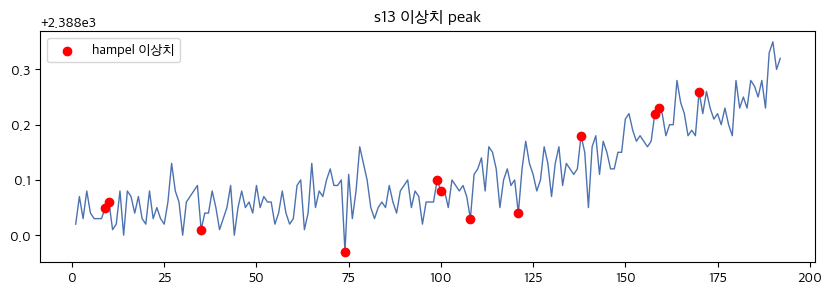

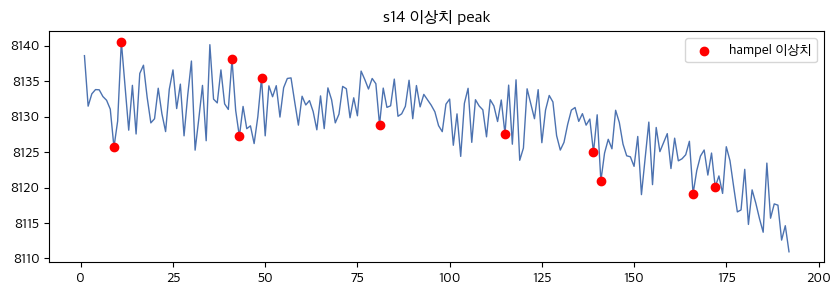

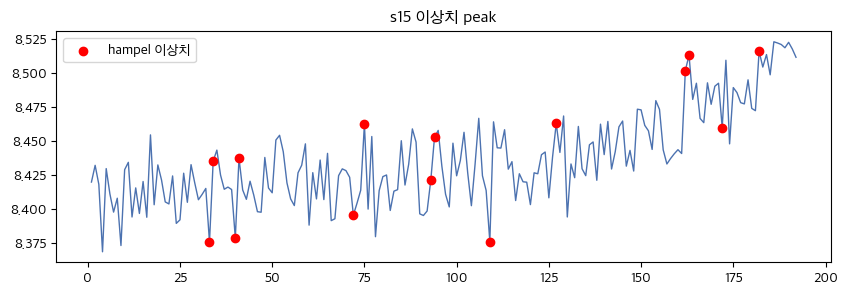

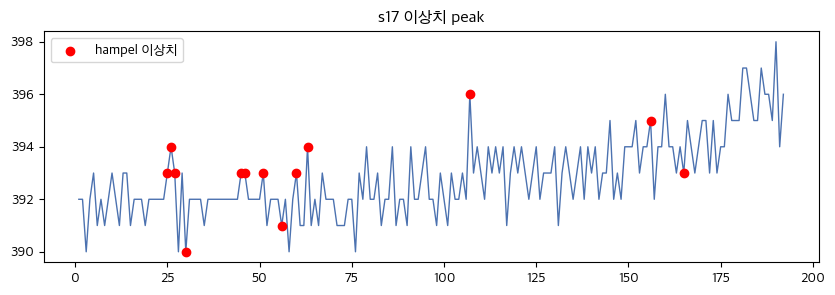

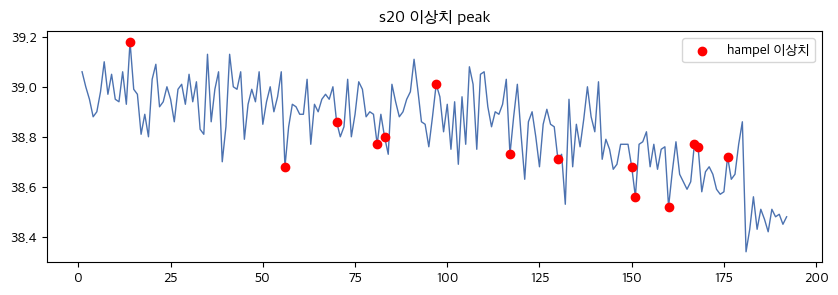

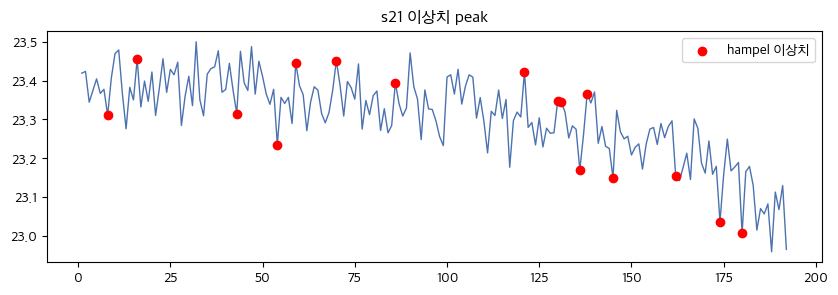

In [ ]:
results = []
for col in sensor_cols:
    s = engine1[col]

    if col == 's17':
        filtered, outlier = hampel_filter(s, window=8, k=3)
    else:
        filtered, outlier = hampel_filter(s, window=5, k=3)

    n_unique = s.nunique()
    outlier_pct = outlier.sum() / len(s) * 100
    var_before = s.var()
    var_after = filtered.var()
    var_reduction_pct = (1 - var_after / var_before) * 100 if var_before > 0 else None

    corr_before = s.corr(engine1['cycle'], method='pearson')
    corr_after = filtered.corr(engine1['cycle'], method='pearson')
    
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(engine1['cycle'], engine1[col], linewidth=1, color="#4C72B0")
    ax.scatter(engine1['cycle'][outlier], engine1[col][outlier],
            color="#CF6D47", zorder=5, label="hampel 이상치")
    ax.legend()
    ax.set_title(f"{col} 이상치 peak")

    results.append({
        'sensor': col,
        'n_unique': n_unique,
        'outlier_pct': outlier_pct,
        'var_reduction_pct': var_reduction_pct,
        'corr_before': corr_before,
        'corr_after': corr_after,
        'corr_change': abs(corr_after) - abs(corr_before)
    })

summary = pd.DataFrame(results).sort_values('outlier_pct', ascending=False)
summary

/var/folders/w5/9zknfqrs3dn6cmzpl11fhmmw0000gn/T/ipykernel_81500/2887562009.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[393.  393.  393.  393.  393.  393.  393.  393.  393.  393.  393.  393.5
 394.  394.  394.  394.  395.  395. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  filtered[outlier] = rolling_median[outlier]


,sensor,n_unique,outlier_pct,var_reduction_pct,corr_before,corr_after,corr_change
7,s12,138,10.606061,8.496933,-0.820075,-0.841718,0.021643
11,s17,8,9.090909,13.514748,0.702810,0.728100,0.025290
1,s3,195,8.080808,1.502199,0.706879,0.733678,0.026799
10,s15,175,8.080808,7.179119,0.734966,0.742083,0.007118
9,s14,189,7.575758,5.904081,0.829843,0.834058,0.004215
5,s9,191,7.070707,-0.940711,0.836487,0.837308,0.000822
12,s20,63,7.070707,9.132458,-0.756968,-0.779419,0.022451
0,s2,120,6.060606,8.273888,0.692500,0.709665,0.017165
13,s21,194,6.060606,-0.718624,-0.731041,-0.765511,0.034470
3,s7,135,5.555556,4.411234,-0.792186,-0.803947,0.011762


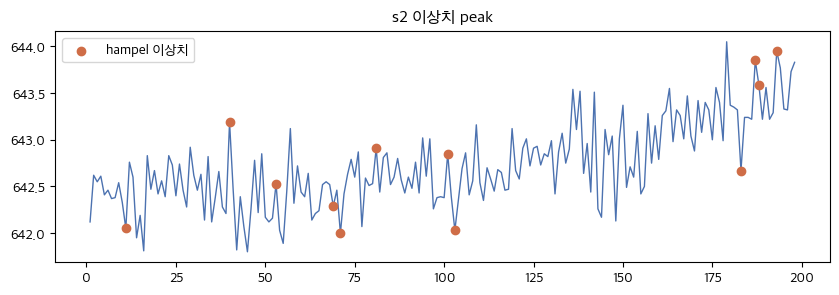

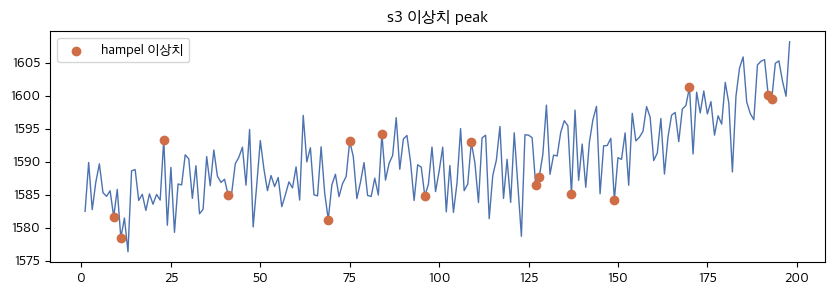

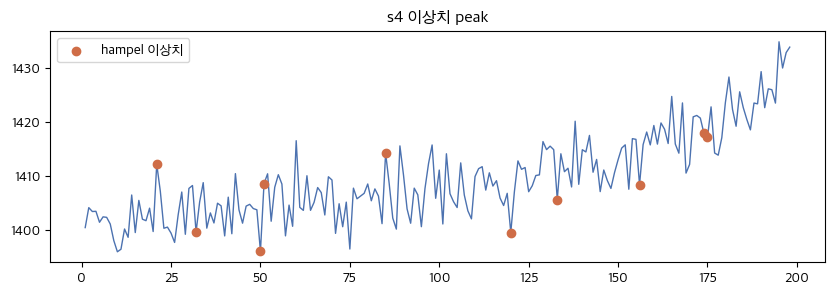

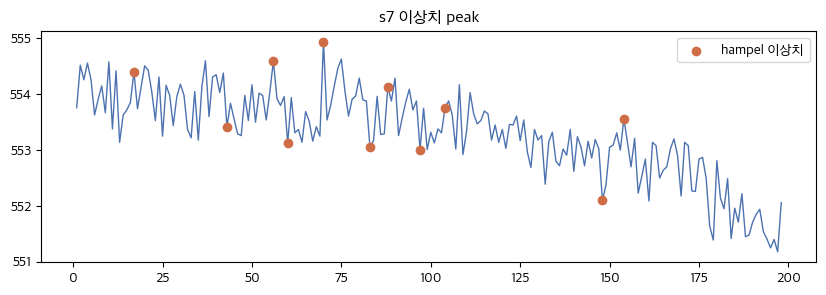

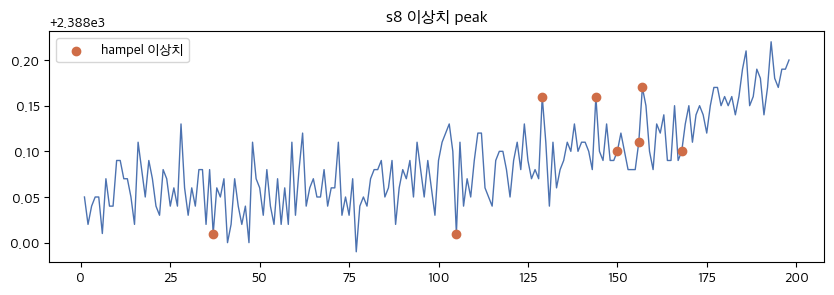

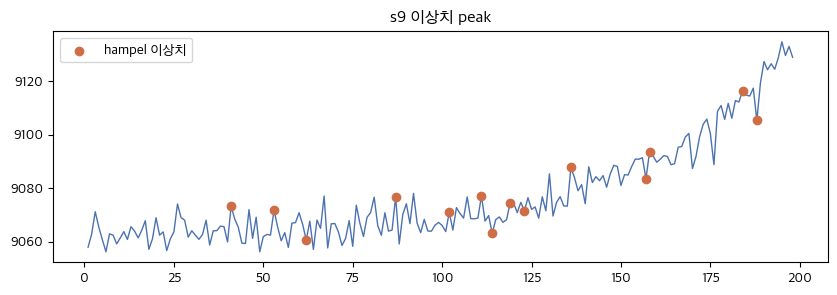

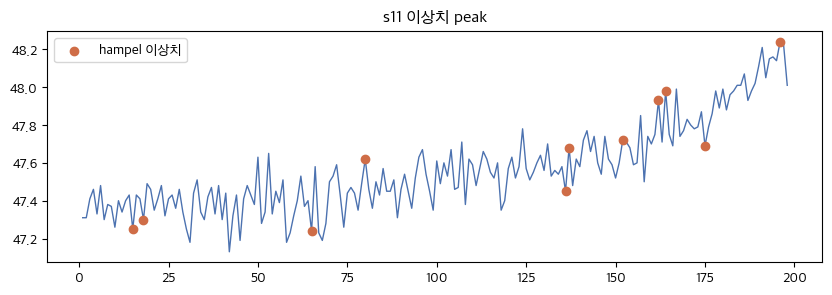

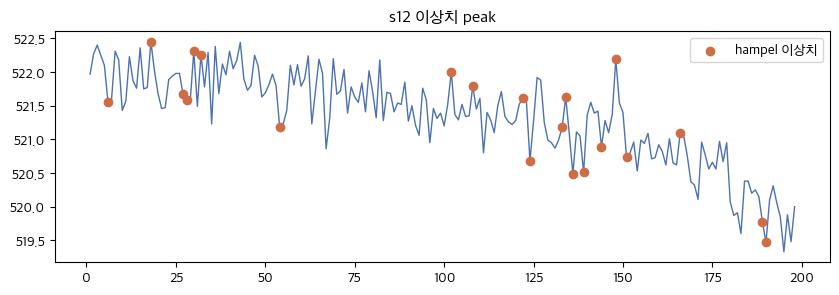

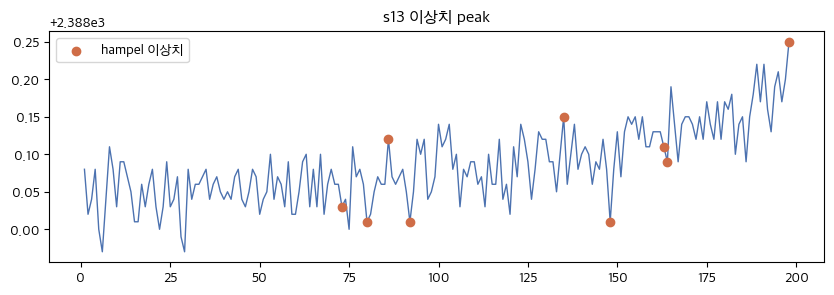

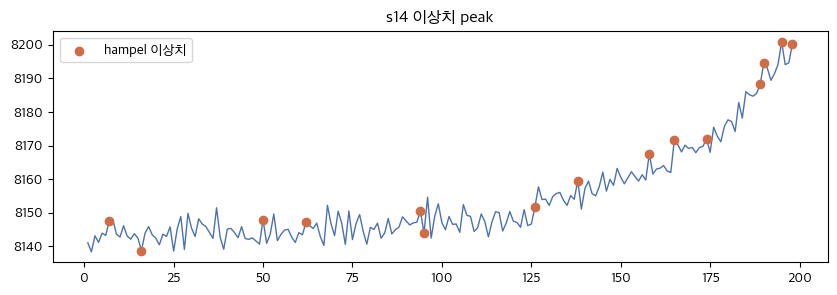

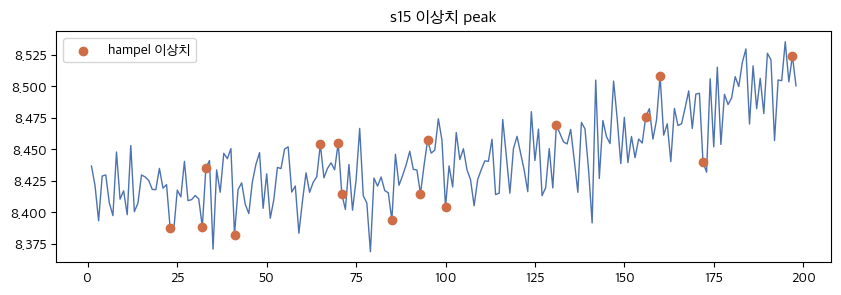

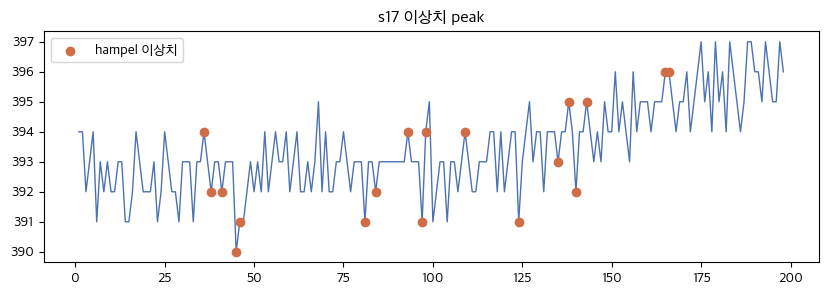

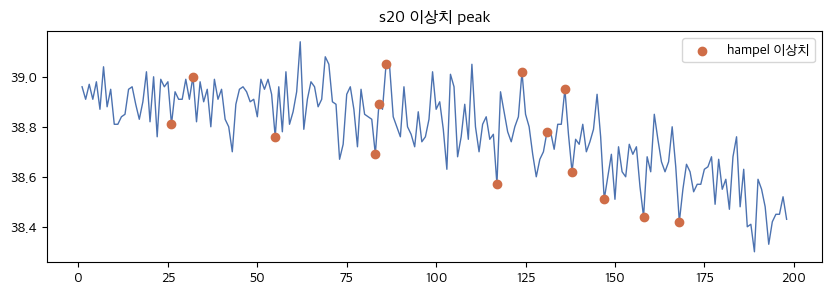

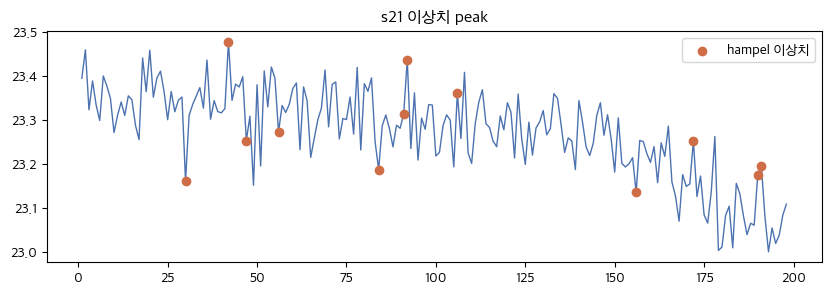

In [133]:
engine50 = train1[train1['engine_id']==50]
results = []
for col in sensor_cols:
    s = engine50[col]
    if col == 's17':
        filtered, outlier = hampel_filter(s, window=8, k=3)
    else:
        filtered, outlier = hampel_filter(s, window=5, k=3)

    n_unique = s.nunique()
    outlier_pct = outlier.sum() / len(s) * 100
    var_before = s.var()
    var_after = filtered.var()
    var_reduction_pct = (1 - var_after / var_before) * 100 if var_before > 0 else None

    corr_before = s.corr(engine50['cycle'], method='pearson')
    corr_after = filtered.corr(engine50['cycle'], method='pearson')

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(engine50['cycle'], engine50[col], linewidth=1, color="#4C72B0")
    ax.scatter(engine50['cycle'][outlier], engine50[col][outlier],
            color="#CF6D47", zorder=5, label="hampel 이상치")
    ax.legend()
    ax.set_title(f"{col} 이상치 peak")

    results.append({
        'sensor': col,
        'n_unique': n_unique,
        'outlier_pct': outlier_pct,
        'var_reduction_pct': var_reduction_pct,
        'corr_before': corr_before,
        'corr_after': corr_after,
        'corr_change': abs(corr_after) - abs(corr_before)
    })

summary = pd.DataFrame(results).sort_values('outlier_pct', ascending=False)
summary

,sensor,n_unique,outlier_pct,var_reduction_pct,corr_before,corr_after,corr_change
2,s4,222,11.111111,9.121953,0.791791,0.803575,0.011783
11,s17,8,10.256410,10.820374,0.684278,0.745810,0.061532
3,s7,154,9.401709,7.031057,-0.715865,-0.710958,-0.004907
10,s15,202,8.119658,13.676373,0.642616,0.641988,-0.000628
9,s14,209,7.692308,14.520922,0.594010,0.602624,0.008613
0,s2,118,7.264957,5.077910,0.581152,0.591010,0.009858
5,s9,222,6.837607,7.924754,0.746840,0.763936,0.017096
6,s11,81,6.837607,7.276344,0.811097,0.820344,0.009247
8,s13,28,5.982906,8.339995,0.733694,0.747416,0.013722
1,s3,219,5.555556,6.804843,0.675420,0.703877,0.028457


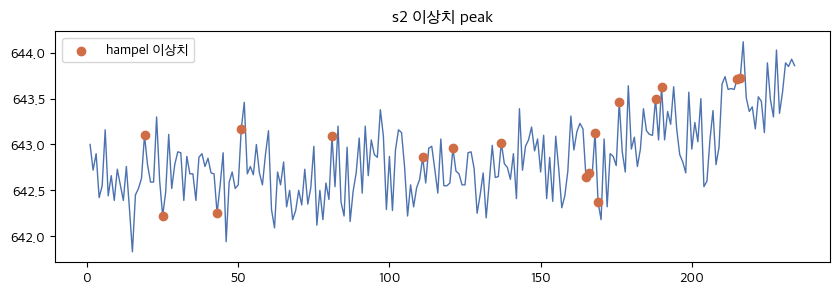

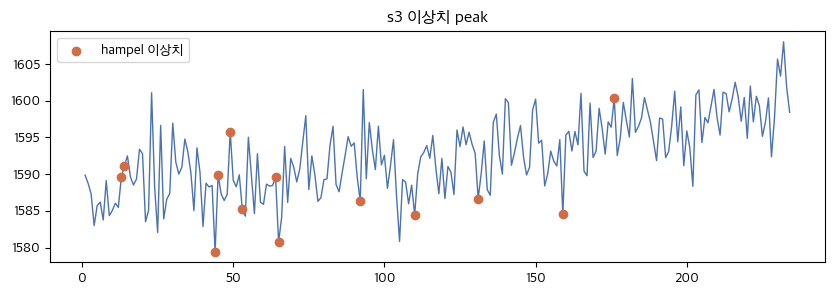

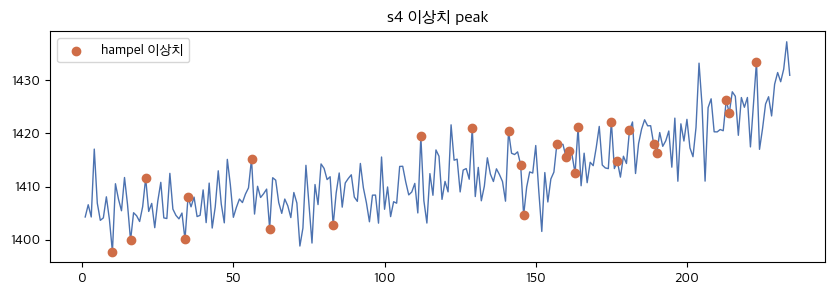

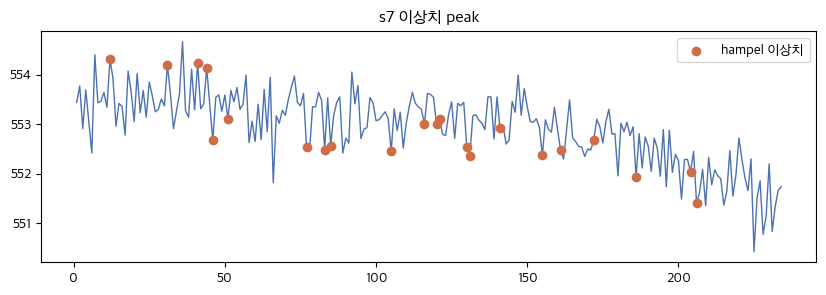

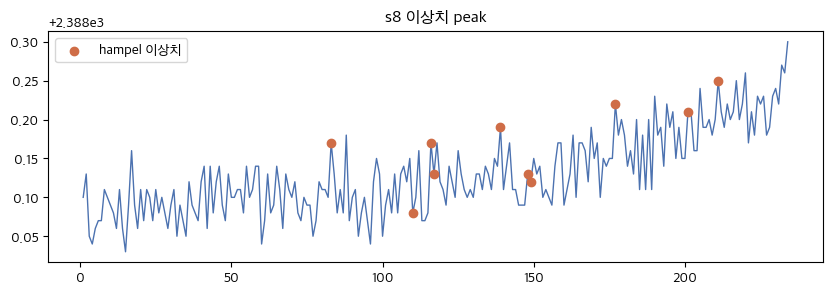

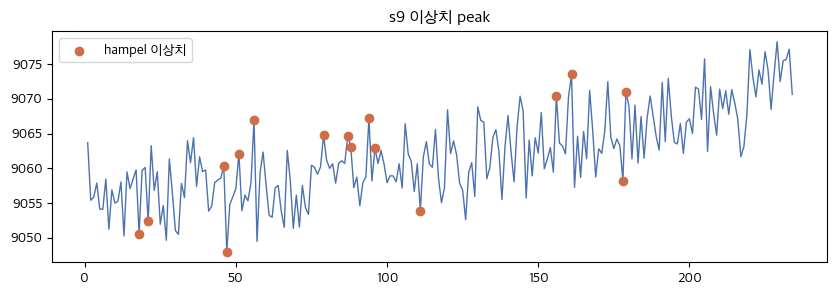

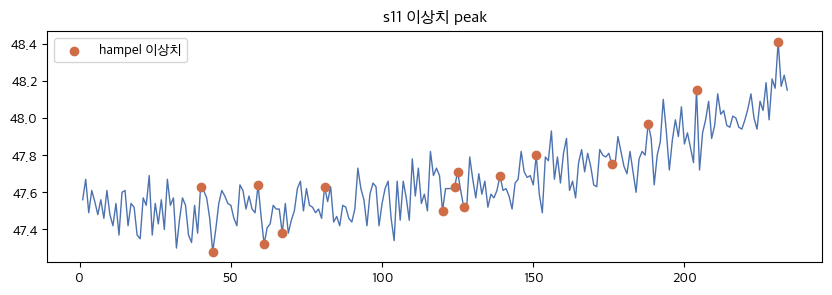

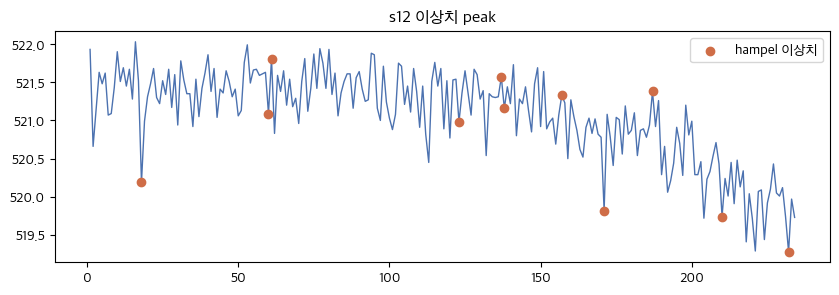

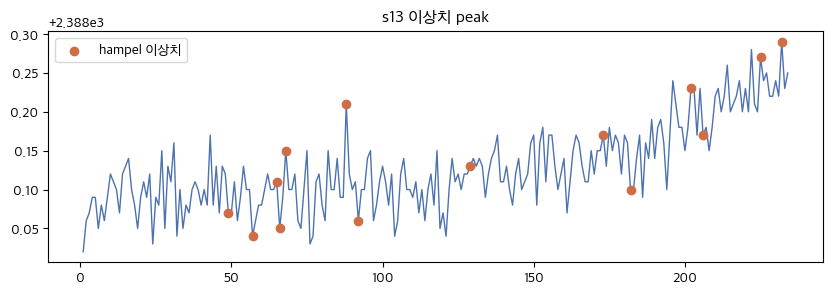

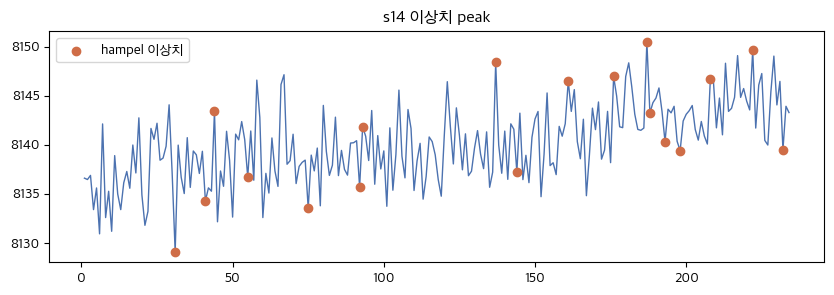

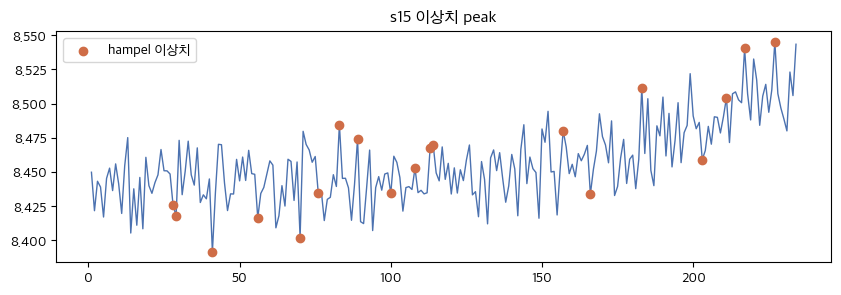

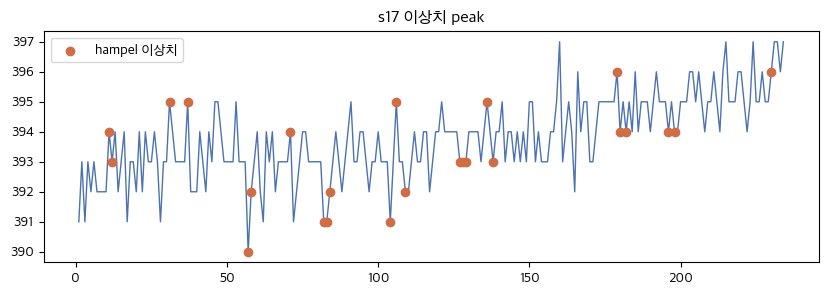

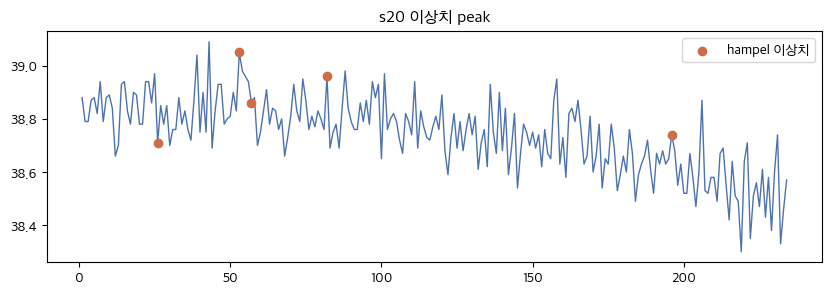

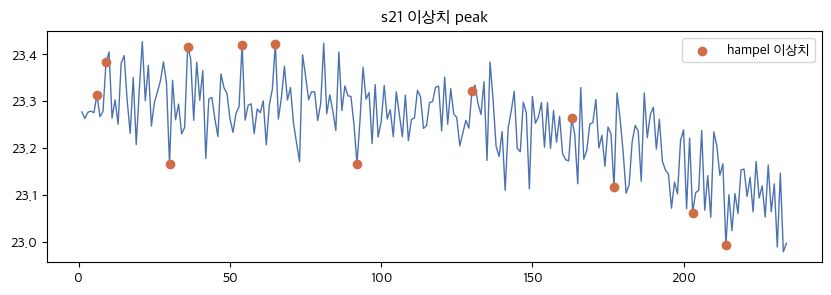

In [164]:
engine20 = train1[train1['engine_id']==20]
results = []
for col in sensor_cols:
    s = engine20[col]
    if col == 's17':
        filtered, outlier = hampel_filter(s, window=8, k=3)
    else:
        filtered, outlier = hampel_filter(s, window=5, k=3)

    n_unique = s.nunique()
    outlier_pct = outlier.sum() / len(s) * 100
    var_before = s.var()
    var_after = filtered.var()
    var_reduction_pct = (1 - var_after / var_before) * 100 if var_before > 0 else None

    corr_before = s.corr(engine20['cycle'], method='pearson')
    corr_after = filtered.corr(engine20['cycle'], method='pearson')

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(engine20['cycle'], engine20[col], linewidth=1, color="#4C72B0")
    ax.scatter(engine20['cycle'][outlier], engine20[col][outlier],
            color="#CF6D47", zorder=5, label="hampel 이상치")
    ax.legend()
    ax.set_title(f"{col} 이상치 peak")

    results.append({
        'sensor': col,
        'n_unique': n_unique,
        'outlier_pct': outlier_pct,
        'var_reduction_pct': var_reduction_pct,
        'corr_before': corr_before,
        'corr_after': corr_after,
        'corr_change': abs(corr_after) - abs(corr_before)
    })

summary = pd.DataFrame(results).sort_values('outlier_pct', ascending=False)
summary

### 실제로 필터가 이상치로 판단한 점을 찍어봤을 때 초반 센서들에서 말기신호에 이상치가 몰리는 경향이 있다. 
1. 전체 엔진 모두 필터를 씌우고,
2. 센서별로 이상치가 말기쪽에 몰리는 것이 맞는지 실제로 확인

In [169]:
print(train1['engine_id'].nunique(), sorted(train1['engine_id'].unique())[:5], sorted(train1['engine_id'].unique())[-5:])

all_results = []
filtered_parts = []   # 엔진별 필터링된 DataFrame을 모아둘 리스트
flag_parts = []       # (선택) 이상치 여부 True/False 표, 검증용
engine_ids = train1['engine_id'].unique()

for eid in engine_ids:
    mask = (train1['engine_id'] == eid)
    orig_index = train1.index[mask]                 # train1에서의 원래 인덱스 보관
    eng = train1[mask].reset_index(drop=True)       # 계산용: 인덱스 꼬임 방지
    max_cycle = eng['cycle'].max()

    eng_f = eng.copy()                              # 필터링 결과를 담을 복사본 (센서 외 컬럼은 그대로)
    eng_flag = pd.DataFrame(False, index=eng.index, columns=sensor_cols)

    for col in sensor_cols:
        s = eng[col]
        w = 8 if col == 's17' else 5
        filtered, outlier = hampel_filter(s, window=w, k=3)

        filtered = pd.Series(np.asarray(filtered, dtype=float), index=eng.index)
        filtered = filtered.fillna(s)               # 윈도우 초반 NaN이 있으면 원본으로 채움 [확인 필요]
        outlier = np.asarray(outlier, dtype=bool)

        eng_f[col] = filtered.values                # 필터링된 값으로 교체
        eng_flag[col] = outlier

        dev = (s.values - filtered.values)[outlier] # 원값 - 대체값 (말기 쏠림 방향 진단용)
        for c, d in zip(eng['cycle'].values[outlier], dev):
            all_results.append({
                'engine_id': eid, 'sensor': col, 'cycle': c,
                'max_cycle': max_cycle, 'life_pct': c / max_cycle, 'dev': d
            })

    eng_f.index = orig_index                        # train1과 같은 인덱스로 복원
    eng_flag.index = orig_index
    filtered_parts.append(eng_f)
    flag_parts.append(eng_flag)

outlier_df = pd.DataFrame(all_results)
train1_filtered = pd.concat(filtered_parts).sort_index()   # train1과 동일한 행 순서
train1_flags = pd.concat(flag_parts).sort_index()

100 [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)] [np.int64(96), np.int64(97), np.int64(98), np.int64(99), np.int64(100)]


/var/folders/w5/9zknfqrs3dn6cmzpl11fhmmw0000gn/T/ipykernel_81500/2887562009.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[392.  392.  392.  392.5 392.  392.  392.  392.  392.  391.5 392.  394.
 394. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  filtered[outlier] = rolling_median[outlier]
/var/folders/w5/9zknfqrs3dn6cmzpl11fhmmw0000gn/T/ipykernel_81500/2887562009.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[391.  391.  391.  390.5 391.  391.  391.  392.  392.  392.  391.  391.
 392.  392.  391.5 391.  392.  393.  393.  394.  394.  394.  394.  394.
 394.5 395.  395.  395.  395.  396. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  filtered[outlier] = rolling_median[outlier]
/var/folders/w5/9zknfqrs3dn6cmzpl11fhmmw0000gn

In [170]:
# 필터링 x vs 필터링 o 확인

# 1) 모양/인덱스/컬럼 동일한가
print(train1_filtered.shape == train1.shape,
      train1_filtered.index.equals(train1.index),
      list(train1_filtered.columns) == list(train1.columns))

# 2) 센서가 아닌 컬럼(engine_id, cycle, op1~3)은 그대로인가
non_sensor = [c for c in train1.columns if c not in sensor_cols]
print(train1_filtered[non_sensor].equals(train1[non_sensor]))

# 3) NaN이 새로 생기진 않았나
print(train1_filtered[sensor_cols].isna().sum().sum())

# 4) 실제로 바뀐 셀 수 == 이상치로 찍힌 셀 수인가
changed = (train1_filtered[sensor_cols] != train1[sensor_cols]).sum().sum()
print(changed, train1_flags.sum().sum(), len(outlier_df))

True True True
True
0
20299 20299 20299


In [172]:
train1_filtered.to_csv('../data/2차 전처리(헴펠필터)/train1_hampel.csv')

### 이상치로 판단한 점들이 후미 부분에 몰려있는지 확인

In [161]:
TAIL_THRESHOLD = 0.8  # 수명 마지막 20% [가정 - 조정 가능]
outlier_df['is_tail'] = outlier_df['life_pct'] >= TAIL_THRESHOLD

# (A) 엔진 단위 - 전체 센서 합쳐서 빠르게 스캔
tail_ratio_engine = (
    outlier_df.groupby('engine_id')['is_tail']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'tail_outlier_ratio', 'count': 'n_outliers'})
    .reset_index()
    .sort_values('tail_outlier_ratio', ascending=False)
)

# (B) 엔진 x 센서 단위 - 어떤 센서가 문제인지 세부 확인
tail_ratio_sensor = (
    outlier_df.groupby(['engine_id', 'sensor'])['is_tail']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'tail_outlier_ratio', 'count': 'n_outliers'})
    .reset_index()
    .sort_values('tail_outlier_ratio', ascending=False)
)

tail_ratio_engine.head(10)

,engine_id,tail_outlier_ratio,n_outliers
50,51,0.285714,147
76,77,0.284314,102
23,24,0.283186,113
13,14,0.282051,117
70,71,0.281250,128
26,27,0.280374,107
20,21,0.277778,126
86,87,0.277778,108
8,9,0.276471,170
14,15,0.275362,138


In [ ]:
# 엔진아이디별 어떤 센서가 뒤쪽에 많이 몰려있는지.
tail_ratio_sensor

,engine_id,sensor,tail_outlier_ratio,n_outliers
847,61,s20,1.00,5
42,4,s11,1.00,4
626,45,s4,0.80,5
182,14,s11,0.75,4
194,14,s8,0.75,4
...,...,...,...,...
921,66,s7,0.00,10
917,66,s20,0.00,7
916,66,s2,0.00,7
913,66,s14,0.00,7


In [ ]:
tail_ratio_sensor[tail_ratio_sensor['tail_outlier_ratio'] > 0.3]['sensor'].value_counts()

sensor
s9     35
s4     33
s14    30
s8     29
s7     29
s13    27
s11    26
s3     26
s21    25
s12    23
s2     22
s20    20
s17    20
s15    20
Name: count, dtype: int64

### 말기 쪽에 몰리는 현상이 있기는 하지만, 실제값 - 윈도우 5 단위 중앙갑들을 계산했을 때 정규분포에 가까우므로, 헴펠필터가 필수적으로 필요한 상황은 아니라고 판단하였다. 
k = 4로 했을 때보다 k=3으로 했을 때 말기 편향이 적었다. 따라서 헴펠필터(window=5,k=3) vs 노이즈 제거 x로 모델을 비교한다. 

In [168]:
filtered

0      23.3899
1      23.2460
2      23.2034
3      23.2495
4      23.2351
        ...   
195    22.9735
196    23.1594
197    22.9333
198    23.0640
199    23.0522
Name: s21, Length: 200, dtype: float64

### s17같은 경우에, 계단처럼 뚝뚝 끊기는 경향이 보이기 때문에 양자화 노이즈를 추정할 수 있다. 확인해보자

In [12]:
s17_val = sorted(train1['s17'].unique())
diffs = pd.Series(s17_val).diff().dropna()
diffs.value_counts()

1.0    12
Name: count, dtype: int64

In [13]:
print('행의 개수 : ',len(train1['s17']))
print('고유값 개수 : ',train1['s17'].nunique())

행의 개수 :  20631
고유값 개수 :  13


In [14]:
print('엔진 1의 행의 개수 : ',len(train1[train1['engine_id']==1]['s17']))
print('엔진 1의 고유값의 개수 : ',train1[train1['engine_id']==1]['s17'].nunique())

엔진 1의 행의 개수 :  192
엔진 1의 고유값의 개수 :  9


In [ ]:
print('엔진 1의 행의 개수 : ',len(train1[train1['engine_id']==50]['s17']))
print('엔진 1의 고유값의 개수 : ',train1[train1['engine_id']==50]['s17'].nunique())

엔진 1의 행의 개수 :  198
엔진 1의 고유값의 개수 :  8


간격이 정확히 1로만 이루어져있기 떄문에 노이즈라기 보다는 양자화되어있는 값 자체로 봐야함.
또한 엔진 아이디를 특정하여 확인했을 때도 전체에 비해 고유값의 개수가 크게 적지 않으므로 더 데이터를 파악할 필요가 있음.

In [24]:
train1['s2']

0        641.82
1        642.15
2        642.35
3        642.35
4        642.37
          ...  
20626    643.49
20627    643.54
20628    643.42
20629    643.23
20630    643.85
Name: s2, Length: 20631, dtype: float64